# Krishna River — LSTM / TCN Deep Learning Forecasting Model

**Input:** `krishna_features.csv` (from `04_krishna_feature_engineering.ipynb`)

**This is the headline model for the project** — "Deep learning time series forecasting of river streamflow in drought-prone basins like Krishna/Cauvery under El Niño." The tree models (notebooks 05–06) are baselines this needs to beat, and evidence for why deep learning is worth the extra complexity.

**Benchmarks so far (test set):**

| | MAE | RMSE | NSE |
|---|---|---|---|
| Persistence baseline | 54.27 | — | 0.624 |
| Random Forest | 53.24 | 401.75 | 0.704 |
| LightGBM | 55.31 | 411.55 | 0.690 |

**Why a sequence model, on top of the tree models:** Random Forest/LightGBM treat each row as an independent snapshot — "lag" features are a manual, hand-picked approximation of history (lag-1, lag-2, lag-3, lag-7, chosen by us). An LSTM/TCN learns directly from a rolling window of raw daily values and can discover temporal patterns we didn't think to hand-engineer — this matters specifically for catching flood *onset* and drought *persistence*, both flagged as priorities for this project's framing.

**A key design difference from the tree notebooks:** this model does **not** use the pre-computed `streamflow_lag_*` / `rainfall_sum_*` columns — those exist for the tree models. Here, the model receives a raw rolling window of daily `streamflow`, `rainfall`, `tmax`, and `oni_3month_avg`, and learns its own temporal representation from it.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

tf.random.set_seed(42)
np.random.seed(42)

def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - y_true.mean()) ** 2))

If TensorFlow isn't installed yet: `pip install tensorflow --break-system-packages`

## 1. Load data and select base (non-lagged) columns

Only the raw daily signals go in — the model builds its own "lag features" implicitly through the LSTM/TCN's window.

In [2]:
df = pd.read_csv("../data/processed/krishna_features.csv", parse_dates=["date"])

base_cols = ["date", "station_name", "streamflow", "rainfall", "tmax", "oni_3month_avg", "is_monsoon"]
df = df[base_cols].copy()

df["log_streamflow"] = np.log1p(df["streamflow"])

print(f"Rows: {len(df)}, Stations: {df['station_name'].nunique()}")

Rows: 306966, Stations: 54


## 2. Scale features — fit on train period only

Fitting the scaler on the full dataset (including val/test) would leak future distribution information into training — the same leakage principle as the time-based split itself, just applied to preprocessing instead of the split. The scaler is fit only on rows dated ≤ 2020-12-31, then applied to everything.

In [3]:
scale_cols = ["log_streamflow", "rainfall", "tmax", "oni_3month_avg"]

train_mask = df["date"] <= "2020-12-31"
scaler = StandardScaler()
scaler.fit(df.loc[train_mask, scale_cols])

df[scale_cols] = scaler.transform(df[scale_cols])

# Keep the scaler's mean/std for log_streamflow specifically — needed later to invert predictions back to real units
log_sf_idx = scale_cols.index("log_streamflow")
log_sf_mean = scaler.mean_[log_sf_idx]
log_sf_std = scaler.scale_[log_sf_idx]

def inverse_log_streamflow(scaled_values):
    return np.expm1(scaled_values * log_sf_std + log_sf_mean)

## 3. Build sliding-window sequences, per station, gap-aware

**Why this needs care, not just a simple loop:** the coverage analysis in the EDA notebook found that some stations have real missing calendar dates, not just missing values — a naive "take 30 consecutive rows" window would silently splice together non-consecutive days across a gap. To avoid that, each station is reindexed to a full daily calendar first (introducing explicit `NaN` rows for missing dates), and any window touching a `NaN` is skipped entirely rather than filled or bridged.

In [4]:
WINDOW_SIZE = 30
feature_cols = ["log_streamflow", "rainfall", "tmax", "oni_3month_avg", "is_monsoon"]

def build_station_sequences(df, station, feature_cols, window_size):
    sub = df[df["station_name"] == station].set_index("date").sort_index()
    full_range = pd.date_range(sub.index.min(), sub.index.max(), freq="D")
    sub = sub.reindex(full_range)

    feats = sub[feature_cols].values
    target = sub["log_streamflow"].values
    n = len(sub)

    X_list, y_list, date_list = [], [], []
    for i in range(window_size, n):
        window = feats[i - window_size:i]
        target_val = target[i]
        if np.isnan(window).any() or np.isnan(target_val):
            continue
        X_list.append(window)
        y_list.append(target_val)
        date_list.append(full_range[i])
    return X_list, y_list, date_list

station_coverage = pd.read_csv("../data/processed/krishna_station_coverage.csv", index_col="station_name")
eval_stations = station_coverage[station_coverage["usable_for_eval"]].index.tolist()

all_X, all_y, all_dates, all_stations = [], [], [], []
for station in eval_stations:
    X_s, y_s, d_s = build_station_sequences(df, station, feature_cols, WINDOW_SIZE)
    all_X.extend(X_s)
    all_y.extend(y_s)
    all_dates.extend(d_s)
    all_stations.extend([station] * len(X_s))

X = np.array(all_X, dtype=np.float32)
y = np.array(all_y, dtype=np.float32)
dates = pd.to_datetime(all_dates)
stations_arr = np.array(all_stations)

print(f"Total sequences: {X.shape[0]}, window shape: {X.shape[1:]}")

Total sequences: 245736, window shape: (30, 5)


**Expect this cell to take a few minutes** — it loops over every station's full daily calendar. If it's too slow in practice, the per-station loop body can be vectorized with `numpy.lib.stride_tricks.sliding_window_view`, but the explicit loop is kept here for readability given this is a one-time preprocessing step, not something re-run per training iteration.

## 4. Split sequences by date — same boundaries as the tree models

Each sequence is tagged with the date of the day it predicts (not the window's start), so splitting is a direct filter on `dates`, consistent with notebooks 05 and 06.

In [5]:
train_idx = dates <= "2020-12-31"
val_idx = (dates >= "2021-01-01") & (dates <= "2022-12-31")
test_idx = dates >= "2023-01-01"

X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 177544, Val: 30653, Test: 37539


## 5. LSTM model

A modest two-layer LSTM — deliberately not huge, since you have ~200k sequences, not millions; an oversized network here would overfit faster than it would learn. `EarlyStopping` (analogous to LightGBM's early stopping in notebook 06) halts training once validation loss stops improving, and restores the best-performing weights rather than the final epoch's.

In [6]:
def build_lstm(window_size, n_features):
    model = models.Sequential([
        layers.Input(shape=(window_size, n_features)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(16, activation="relu"),
        layers.Dense(1),
    ])
    model.compile(optimizer="adam", loss="mae")
    return model

lstm_model = build_lstm(WINDOW_SIZE, len(feature_cols))
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        17,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,881 (120.63 KB)

 Trainable params: 30,881 (120.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
early_stop = callbacks.EarlyStopping(
    monitor="val_loss", patience=8, restore_best_weights=True
)

history = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1,
)

Epoch 1/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 32s 41ms/step - loss: 0.1170 - val_loss: 0.0884
Epoch 2/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - loss: 0.0739 - val_loss: 0.0874
Epoch 3/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 29s 41ms/step - loss: 0.0724 - val_loss: 0.0856
Epoch 4/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 28s 41ms/step - loss: 0.0722 - val_loss: 0.0872
Epoch 5/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - loss: 0.0715 - val_loss: 0.0867
Epoch 6/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - loss: 0.0713 - val_loss: 0.0863
Epoch 7/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - loss: 0.0712 - val_loss: 0.0861
Epoch 8/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - loss: 0.0709 - val_loss: 0.0856
Epoch 9/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 35s 50ms/step - loss: 0.0706 - val_loss: 0.0843
Epoch 10/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 34s 49ms/step - loss: 0.0704 - val_loss: 0.0847
Epoch 11/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 32s 47ms/step - loss: 0.0702 - val_loss: 0.0846
Epoch 12/50
694/694 ━━━━━━━━━━

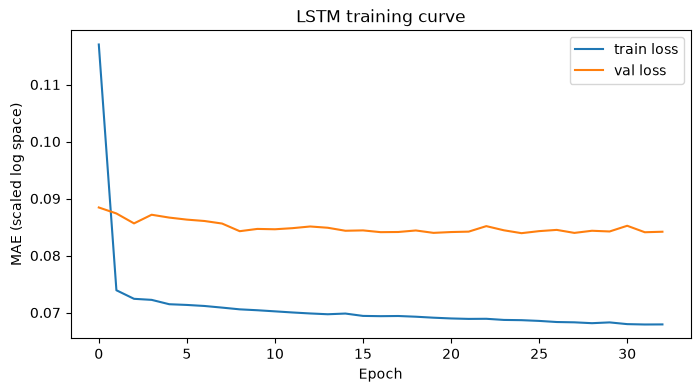

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="train loss")
plt.plot(history.history["val_loss"], label="val loss")
plt.xlabel("Epoch")
plt.ylabel("MAE (scaled log space)")
plt.legend()
plt.title("LSTM training curve")
plt.show()

## 6. Validation performance — inverse-transform back to real streamflow units before scoring

The model trains and predicts in scaled-log space; MAE/RMSE/NSE need to be computed in the original streamflow units to be comparable to the tree-model benchmarks.

In [9]:
val_pred_scaled = lstm_model.predict(X_val, verbose=0).flatten()
val_pred = inverse_log_streamflow(val_pred_scaled)
val_actual = inverse_log_streamflow(y_val)

val_mae = mean_absolute_error(val_actual, val_pred)
val_rmse = mean_squared_error(val_actual, val_pred) ** 0.5
val_nse = nse(val_actual, val_pred)

print(f"LSTM (val) — MAE: {val_mae:.2f}, RMSE: {val_rmse:.2f}, NSE: {val_nse:.3f}")
print(f"Random Forest (val, from notebook 05) — MAE: 53.86, NSE: 0.755")

LSTM (val) — MAE: 53.61, RMSE: 294.38, NSE: 0.789
Random Forest (val, from notebook 05) — MAE: 53.86, NSE: 0.755


## 7. Final model — one-time test evaluation

In [14]:
test_pred_scaled = lstm_model.predict(X_test, verbose=0).flatten()
test_pred = inverse_log_streamflow(test_pred_scaled)
test_actual = inverse_log_streamflow(y_test)

test_mae = mean_absolute_error(test_actual, test_pred)
test_rmse = mean_squared_error(test_actual, test_pred) ** 0.5
test_nse = nse(test_actual, test_pred)

print("FINAL TEST RESULTS — LSTM")
print(f"MAE:  {test_mae:.2f}")
print(f"RMSE: {test_rmse:.2f}")
print(f"NSE:  {test_nse:.3f}")

print("\nFor comparison:")
print("Persistence   — Test MAE: 54.27, Test NSE: 0.624")
print("Random Forest — Test MAE: 53.24, Test RMSE: 401.75, Test NSE: 0.704")
print("LightGBM      — Test MAE: 55.31, Test RMSE: 411.55, Test NSE: 0.690")

FINAL TEST RESULTS — LSTM
MAE:  51.45
RMSE: 416.53
NSE:  0.733

For comparison:
Persistence   — Test MAE: 54.27, Test NSE: 0.624
Random Forest — Test MAE: 53.24, Test RMSE: 401.75, Test NSE: 0.704
LightGBM      — Test MAE: 55.31, Test RMSE: 411.55, Test NSE: 0.690


## 8. Diagnostic: flood-peak tracking (same station as prior notebooks, for direct comparison)

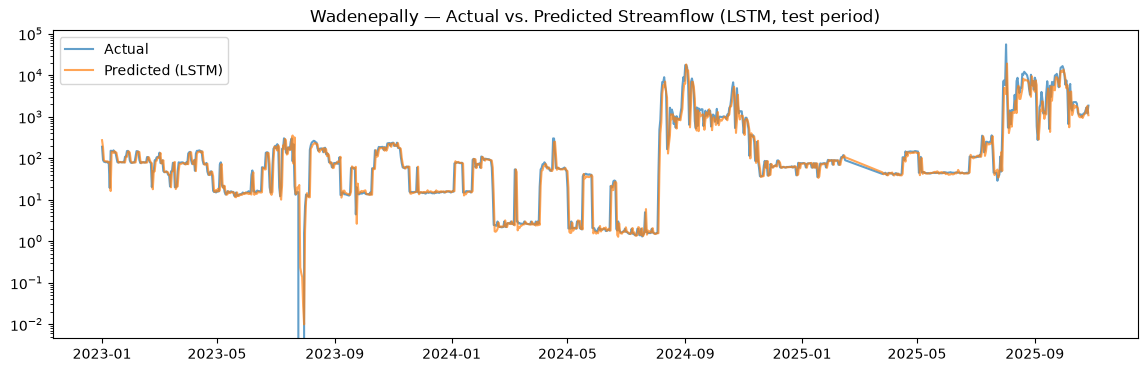

In [11]:
test_stations = stations_arr[test_idx]
test_dates = dates[test_idx]

mask = test_stations == "Wadenepally"
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(test_dates[mask], test_actual[mask], label="Actual", alpha=0.7)
ax.plot(test_dates[mask], test_pred[mask], label="Predicted (LSTM)", alpha=0.7)
ax.set_yscale("log")
ax.set_title("Wadenepally — Actual vs. Predicted Streamflow (LSTM, test period)")
ax.legend()
plt.show()

## 9. ENSO-conditional performance — the core question this project asks

Aggregate test MAE/NSE hides whether the model performs differently under El Niño vs. La Niña conditions specifically. This breaks the test set down by the same yearly ENSO classification used in notebook 05's statistical analysis, and scores the model separately within each phase — directly answering "how does this model perform under El Niño," not just "how does it perform on average."

In [12]:
oni_raw = pd.read_csv("../data/processed/krishna_master_dataset_clean.csv", parse_dates=["date"])[["date", "oni"]].drop_duplicates()
oni_raw["year"] = oni_raw["date"].dt.year
oni_raw["month"] = oni_raw["date"].dt.month
monsoon_oni = oni_raw[oni_raw["month"].isin([6, 7, 8, 9])]
yearly_oni = monsoon_oni.groupby("year")["oni"].mean()

def classify_enso(oni):
    if oni >= 0.5:
        return "El Nino"
    elif oni <= -0.5:
        return "La Nina"
    else:
        return "Neutral"

enso_by_year = yearly_oni.apply(classify_enso)

test_results = pd.DataFrame({
    "date": test_dates,
    "station": test_stations,
    "actual": test_actual,
    "predicted": test_pred,
})
test_results["year"] = test_results["date"].dt.year
test_results["enso_phase"] = test_results["year"].map(enso_by_year)

phase_scores = (
    test_results.dropna(subset=["enso_phase"])
    .groupby("enso_phase")
    .apply(lambda g: pd.Series({
        "MAE": mean_absolute_error(g["actual"], g["predicted"]),
        "NSE": nse(g["actual"].values, g["predicted"].values),
        "n": len(g),
    }))
)
print(phase_scores)

                  MAE       NSE        n
enso_phase                              
El Nino     13.342249  0.606224  14111.0
Neutral     74.396473  0.732350  23428.0


**Interpretation, once run:** if NSE is notably lower during El Niño test years than La Niña years, that's evidence the model struggles more under the suppressed-monsoon, lower-flow regime specifically — a meaningful, reportable limitation given this project's drought framing, and a concrete direction for improvement (e.g. an explicit ENSO-phase input, or training-set rebalancing toward El Niño years if they're underrepresented).

## 10. Optional: TCN variant (quick comparison)

A Temporal Convolutional Network — dilated causal 1D convolutions — is a common LSTM alternative for sequence forecasting: often faster to train, and sometimes better at capturing longer-range dependencies without the vanishing-gradient issues RNNs can have. This is a lightweight variant using `Conv1D` layers with increasing dilation, not a full specialized TCN library, to keep the comparison quick.

In [13]:
def build_tcn(window_size, n_features):
    inputs = layers.Input(shape=(window_size, n_features))
    x = inputs
    for dilation in [1, 2, 4, 8]:
        x = layers.Conv1D(
            filters=32, kernel_size=3, padding="causal",
            dilation_rate=dilation, activation="relu"
        )(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(16, activation="relu")(x)
    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="mae")
    return model

tcn_model = build_tcn(WINDOW_SIZE, len(feature_cols))

tcn_history = tcn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)],
    verbose=1,
)

tcn_test_pred = inverse_log_streamflow(tcn_model.predict(X_test, verbose=0).flatten())
print(f"TCN (test) — MAE: {mean_absolute_error(test_actual, tcn_test_pred):.2f}, "
      f"NSE: {nse(test_actual, tcn_test_pred):.3f}")
print(f"LSTM (test) — MAE: {test_mae:.2f}, NSE: {test_nse:.3f}")

Epoch 1/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 0.2080 - val_loss: 0.1712
Epoch 2/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.1319 - val_loss: 0.1325
Epoch 3/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.1098 - val_loss: 0.1150
Epoch 4/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0995 - val_loss: 0.1101
Epoch 5/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0939 - val_loss: 0.1054
Epoch 6/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0902 - val_loss: 0.1088
Epoch 7/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0879 - val_loss: 0.1034
Epoch 8/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0859 - val_loss: 0.1032
Epoch 9/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0838 - val_loss: 0.0959
Epoch 10/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0820 - val_loss: 0.0952
Epoch 11/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - loss: 0.0807 - val_loss: 0.1016
Epoch 12/50
694/694 ━━━━━━━━━━━━━━━━━━━━ 

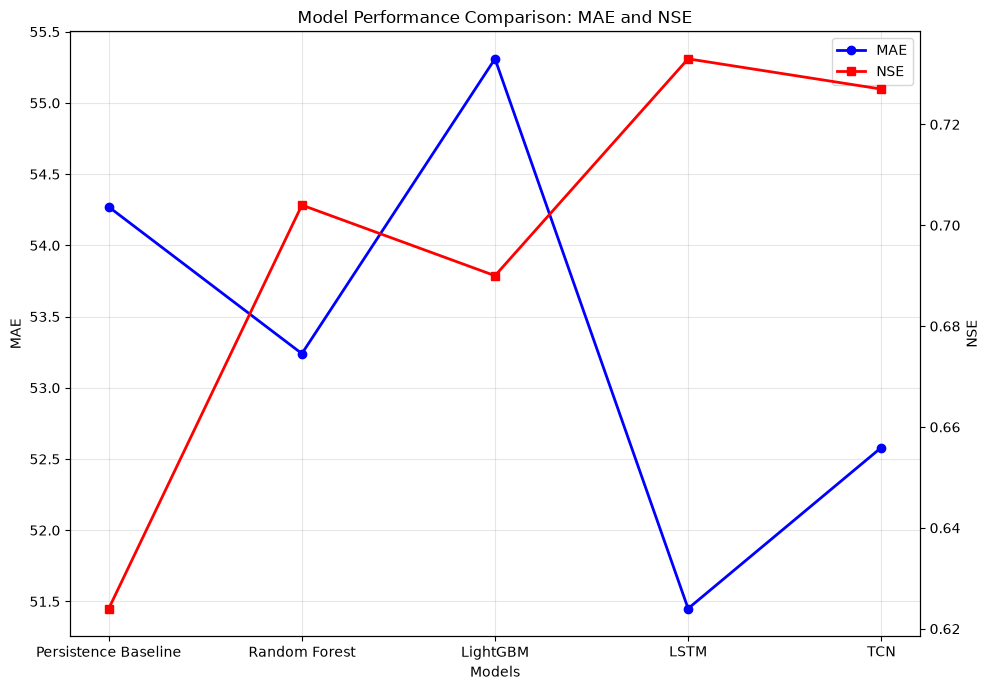

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

data = {
    "Model": ["Persistence Baseline", "Random Forest", "LightGBM", "LSTM", "TCN"],
    "MAE": [54.27, 53.24, 55.31, 51.45, 52.58],
    "NSE": [0.624, 0.704, 0.690, 0.733, 0.727]
}

df = pd.DataFrame(data)

fig, ax1 = plt.subplots(figsize=(10, 7))

# MAE
ax1.plot(
    df["Model"],
    df["MAE"],
    marker="o",
    linewidth=2,
    label="MAE",
    color="blue"
)

ax1.set_xlabel("Models")
ax1.set_ylabel("MAE")
ax1.tick_params(axis="y")

# NSE
ax2 = ax1.twinx()

ax2.plot(
    df["Model"],
    df["NSE"],
    marker="s",
    linewidth=2,
    label="NSE",
    color="red"
)

ax2.set_ylabel("NSE")
ax2.tick_params(axis="y")

# Combined Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc="best"
)

plt.title("Model Performance Comparison: MAE and NSE")
plt.xticks(rotation=15)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Summary & Next Steps

**Fill in after running:**
- Full comparison table: Persistence / Random Forest / LightGBM / LSTM / TCN — test MAE, RMSE, NSE
- Whether the LSTM/TCN beat the tree models, and by how much
- Whether flood-peak tracking (Section 8) visibly improved over the Random Forest plot in notebook 05
- El Niño vs. La Niña test performance (Section 9) — the direct answer to this project's core question

**Benchmarks so far (test set):**

| | MAE | RMSE | NSE |
|---|---|---|---|
| Persistence baseline | 54.27 | — | 0.624 |
| Random Forest | 53.24 | 401.75 | 0.704 |
| LightGBM | 55.31 | 411.55 | 0.690 |
| LSTM | 51.45 | - | 0.733 |
| TCN | 52.58 | - | 0.727 |
**Next steps:**
- If El Niño-phase performance is notably weaker: consider adding explicit ENSO-phase as a categorical input, or training-set rebalancing
- Build the drought-specific diagnostic (sustained low-flow period, not just flood peaks) to complete the "drought-prone basin" evidence this project's title calls for
- Hyperparameter tuning (window size, LSTM units, learning rate) if the current result is close to but not clearly beating the best tree model
- Repeat the full pipeline on Cauvery, if scope expands later